 Matplotlib & Seaborn 

Why visualize data at all?

.describe() gives you numbers, but numbers hide things a mean can look normal while the actual data is two separate clusters, full of outliers, or badly skewed. Visualization is how you see your data before you trust a model with it. This is a core part of EDA (Exploratory Data Analysis) — the step every ML project does before any model is trained.

- Matplotlib = the foundational plotting library in Python : full control, a bit more code.
- Seaborn = built on top of Matplotlib — prettier defaults, works directly with DataFrames, and has statistical plots built in.


1. Why visualize data?
2. Matplotlib basics
3. Core chart types
4. Subplots
5. Enter Seaborn
6. Core Seaborn plots for ML/EDA
7. Live demo: full visual EDA pass
8. Wrap-up


 1. Why Visualize Data?

A famous example: two datasets can have the *exact same* mean, std, and correlation but look completely different when plotted. This is why "check the numbers" is never enough on its own.


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("Matplotlib version:", plt.matplotlib.__version__)
print("Seaborn version:", sns.__version__)

# Quick proof: same mean/std, very different shape
np.random.seed(1)
data_normal = np.random.normal(50, 10, 500)
data_skewed = np.concatenate([np.random.normal(30, 5, 400), np.random.normal(100, 5, 100)])

print("Normal data   - mean:", round(data_normal.mean(), 1), "std:", round(data_normal.std(), 1))
print("Skewed data   - mean:", round(data_skewed.mean(), 1), "std:", round(data_skewed.std(), 1))
print("\n(Similar numbers — but wait until we PLOT these in section 6)")


Matplotlib version: 3.10.9
Seaborn version: 0.13.2
Normal data   - mean: 50.5 std: 9.9
Skewed data   - mean: 44.1 std: 28.5

(Similar numbers — but wait until we PLOT these in section 6)


## 2. Matplotlib Basics

Every Matplotlib plot follows roughly the same recipe: create a figure, plot data, add labels, show it.


In [ ]:
x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.figure(figsize=(8, 4))
plt.plot(x, y)
plt.title("A Simple Line Plot")
plt.xlabel("X values")
plt.ylabel("sin(X)")
plt.grid(True)
plt.show()


Key parts to remember:
- plt.figure(figsize=(w, h)): sets the plot size
- plt.plot(), .title(), .xlabel(), .ylabel() :the standard labeling routine
- plt.show() :renders it

**Why this matters for ML:** this exact pattern is how you'll plot a model's training loss curve over epochs — one of the most common plots in deep learning.


## 3. Core Chart Types

Different chart types answer different questions about your data.


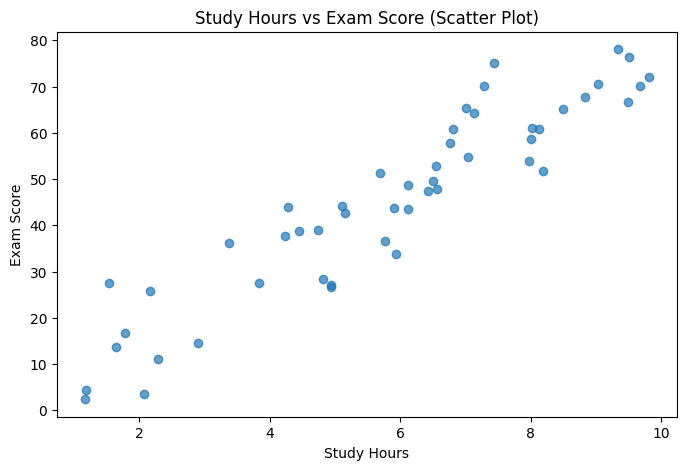

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(8, 5))

# Scatter plot : relationship between two variables
np.random.seed(0)
study_hours = np.random.uniform(1, 10, 50)
scores = study_hours * 8 + np.random.normal(0, 8, 50)

plt.scatter(study_hours, scores, alpha=0.7)
plt.title("Study Hours vs Exam Score (Scatter Plot)")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.show()


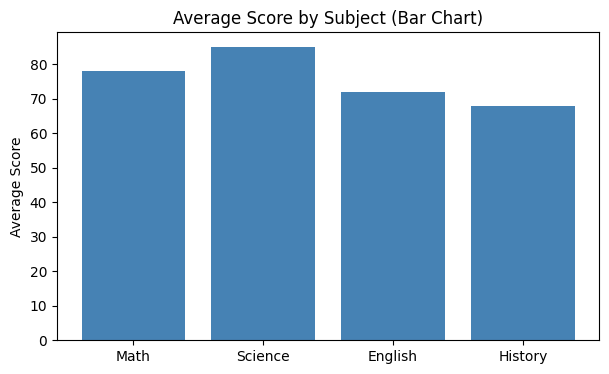

In [ ]:
# Bar chart :comparing categories
categories = ["Math", "Science", "English", "History"]
avg_scores = [78, 85, 72, 68]

plt.figure(figsize=(7, 4))
plt.bar(categories, avg_scores, color="steelblue")
plt.title("Average Score by Subject (Bar Chart)")
plt.ylabel("Average Score")
plt.show()


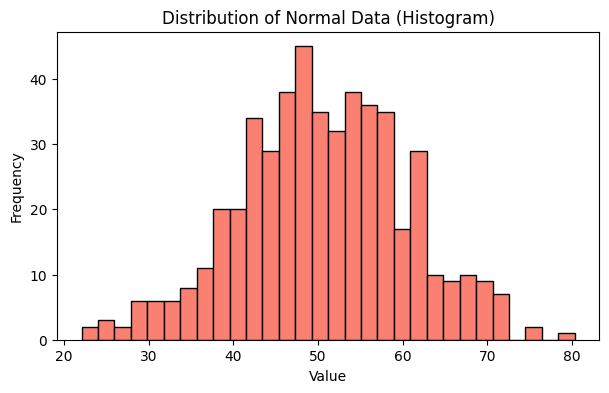

In [ ]:
# Histogram : distribution of a single variable
plt.figure(figsize=(7, 4))
plt.hist(data_normal, bins=30, color="salmon", edgecolor="black")
plt.title("Distribution of Normal Data (Histogram)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


Quick guide to what each chart reveals:
- Scatter → relationship/correlation between two numeric features
- Bar → comparing values across categories
- Histogram → the shape/distribution of one variable (skew, spread, outliers)

**Why this matters for ML:** the scatter plot above already hints that study_hours correlates with scores that's a strong candidate feature, spotted before any model was trained.


## 4. Subplots

Comparing multiple charts side by side, in one figure.


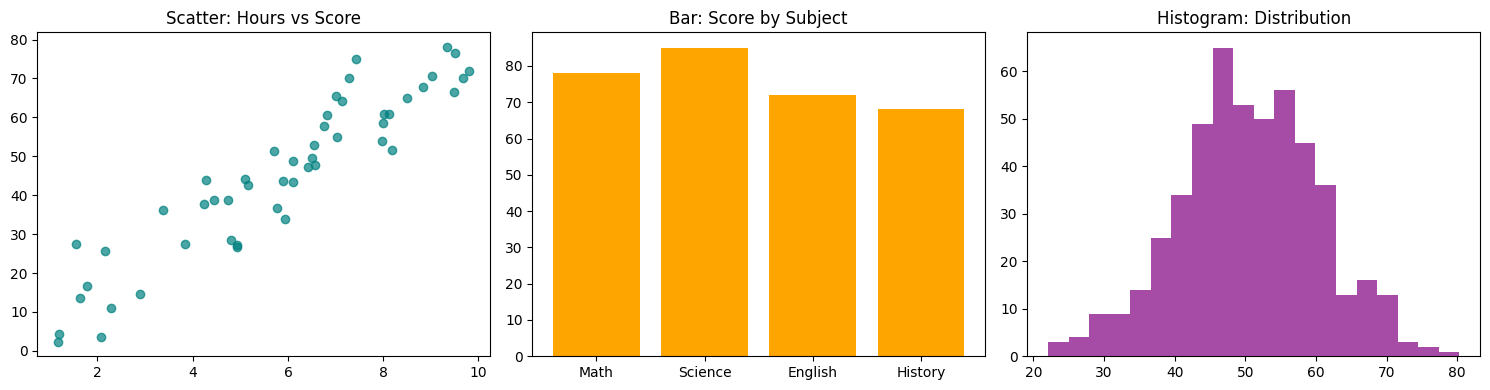

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(study_hours, scores, alpha=0.7, color="teal")
axes[0].set_title("Scatter: Hours vs Score")

axes[1].bar(categories, avg_scores, color="orange")
axes[1].set_title("Bar: Score by Subject")

axes[2].hist(data_normal, bins=20, color="purple", alpha=0.7)
axes[2].set_title("Histogram: Distribution")

plt.tight_layout()
plt.show()


Why this matters for ML: during EDA you'll often want to check the distribution of every feature in a dataset at once  subplots is how you build that grid of charts in one figure instead of scrolling through dozens of separate plots.


## 5. Enter Seaborn

Seaborn is built directly on top of Matplotlib. Three big reasons ML practitioners reach for it:
1. Prettier defaults :good-looking charts with almost no styling code
2. Works natively with DataFrames: pass column names directly, no manual extraction
3. Built-in statistical plots: things like correlation heatmaps and pairplots that would take many lines in raw Matplotlib


In [6]:
# Build a small DataFrame to use for the rest of the notebook
np.random.seed(42)
n = 150

df = pd.DataFrame({
    "study_hours": np.random.uniform(1, 10, n),
    "attendance_pct": np.random.uniform(50, 100, n),
    "sleep_hours": np.random.uniform(4, 9, n),
})
df["previous_score"] = (df["study_hours"] * 6 + df["attendance_pct"] * 0.3
                          + np.random.normal(0, 5, n)).clip(0, 100)
df["passed"] = (df["previous_score"] >= 60).astype(int)

sns.set_style("whitegrid")  # one line for a much nicer look overall
print(df.head())


   study_hours  attendance_pct  sleep_hours  previous_score  passed
0     4.370861       95.413294     4.258409       56.403693       0
1     9.556429       61.978095     6.656773       83.308782       1
2     7.587945       57.244744     6.703176       66.989394       1
3     6.387926       74.472638     7.187150       59.869657       0
4     2.404168       99.282523     7.630457       44.114682       0


## 6. Core Seaborn Plots for ML/EDA

These are the plots you'll actually reach for during real exploratory data analysis.


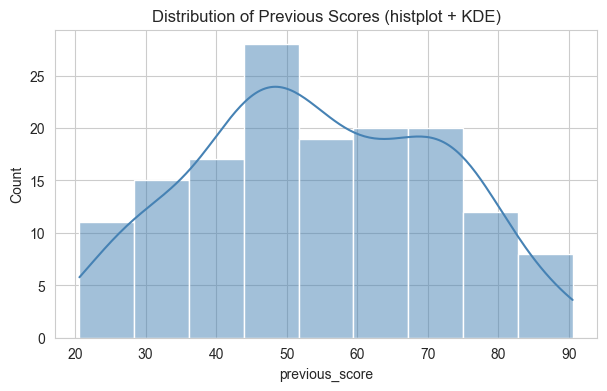

In [ ]:
# Distribution plot with a smooth curve (KDE) :much clearer than a plain histogram
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="previous_score", kde=True, color="steelblue")
plt.title("Distribution of Previous Scores (histplot + KDE)")
plt.show()


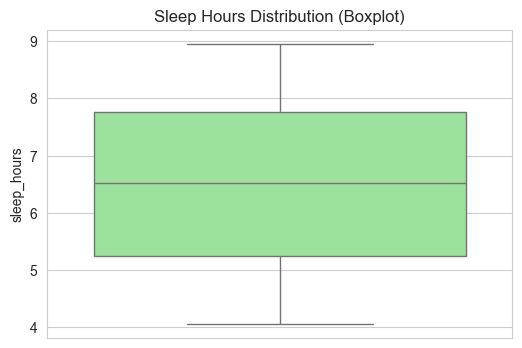

The box shows the middle 50% of values; dots beyond the whiskers are outliers.


In [ ]:
# Boxplot : great for spotting outliers at a glance
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, y="sleep_hours", color="lightgreen")
plt.title("Sleep Hours Distribution (Boxplot)")
plt.show()

print("The box shows the middle 50% of values; dots beyond the whiskers are outliers.")


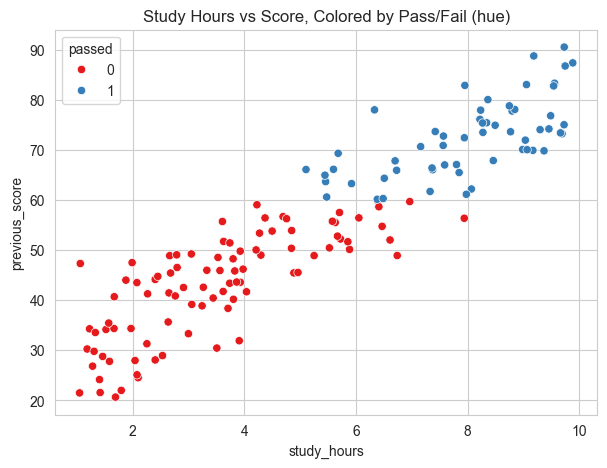

In [ ]:
# Scatter plot with hue : shows class separation, huge for classification problems
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="study_hours", y="previous_score", hue="passed", palette="Set1")
plt.title("Study Hours vs Score, Colored by Pass/Fail (hue)")
plt.show()


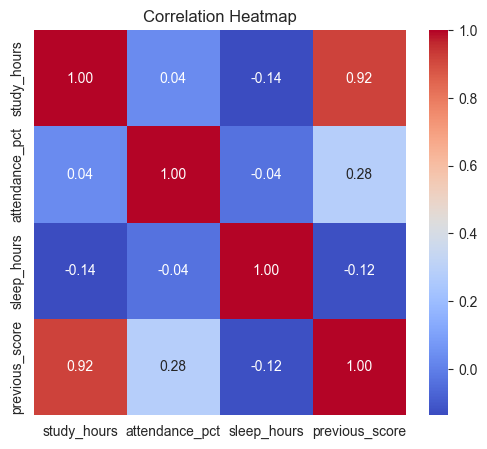

In [ ]:
# Correlation heatmap :one of the most-used EDA plots in ALL of ML
plt.figure(figsize=(6, 5))
correlation_matrix = df[["study_hours", "attendance_pct", "sleep_hours", "previous_score"]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
# Pairplot : every feature plotted against every other feature, in one call
sns.pairplot(df, hue="passed", vars=["study_hours", "attendance_pct", "sleep_hours"], palette="Set1")
plt.suptitle("Pairplot of Features by Pass/Fail", y=1.02)
plt.show()


Why each of these matters for ML:
- histplot/KDE → check if a feature is normally distributed or skewed (some models assume normality)
- boxplot → spot outliers fast outliers can badly distort model training
- scatterplot with hue → visually check if your classes are separable a strong hint about whether a model can learn to tell them apart
- **heatmap** → the fastest way to spot which features are strongly correlated with your target (or redundant with each other)  this directly guides feature selection
- pairplot→ a one line "look at everything at once" view, perfect for a first pass on a new dataset


## 7. Live Demo: Full Visual EDA Pass

Let's run through a realistic mini-EDA workflow, the way you'd actually do it on a new dataset.


In [12]:
print("Step 1: Check overall shape and stats")
print(df.describe())


Step 1: Check overall shape and stats
       study_hours  attendance_pct  sleep_hours  previous_score      passed
count   150.000000      150.000000   150.000000      150.000000  150.000000
mean      5.255984       75.876103     6.480762       54.414553    0.386667
std       2.668777       14.570590     1.506692       17.099971    0.488618
min       1.049699       50.253079     4.054188       20.625173    0.000000
25%       2.933032       62.373882     5.241795       42.522665    0.000000
50%       5.033001       77.800052     6.520972       53.067812    0.000000
75%       7.746957       87.891878     7.765636       68.947435    1.000000
max       9.881982       99.502693     8.952526       90.523414    1.000000


Step 2: Check distributions of all numeric features at once


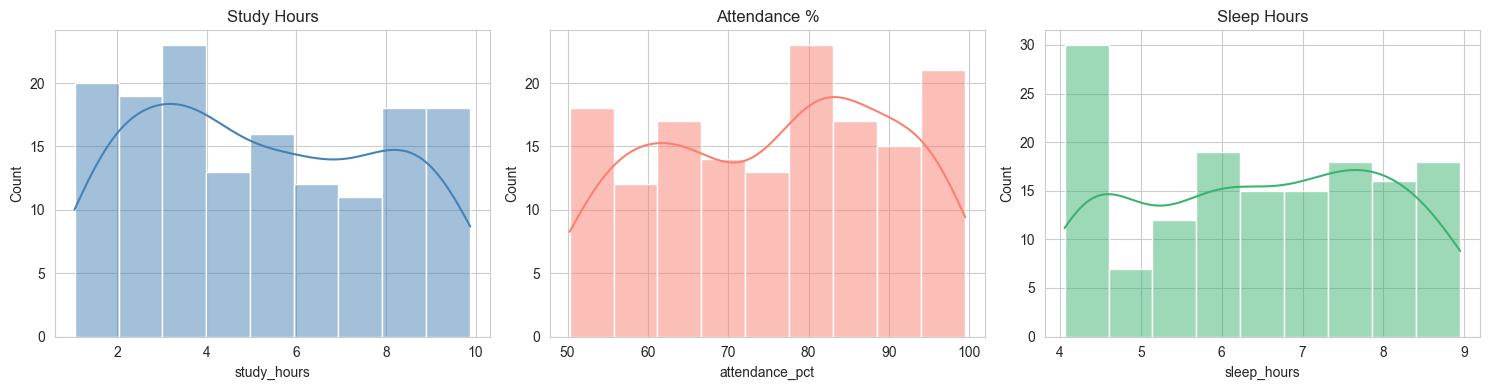

In [11]:
print("Step 2: Check distributions of all numeric features at once")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["study_hours"], kde=True, ax=axes[0], color="steelblue")
sns.histplot(df["attendance_pct"], kde=True, ax=axes[1], color="salmon")
sns.histplot(df["sleep_hours"], kde=True, ax=axes[2], color="mediumseagreen")
axes[0].set_title("Study Hours")
axes[1].set_title("Attendance %")
axes[2].set_title("Sleep Hours")
plt.tight_layout()
plt.show()


Step 3: Check for outliers across all features


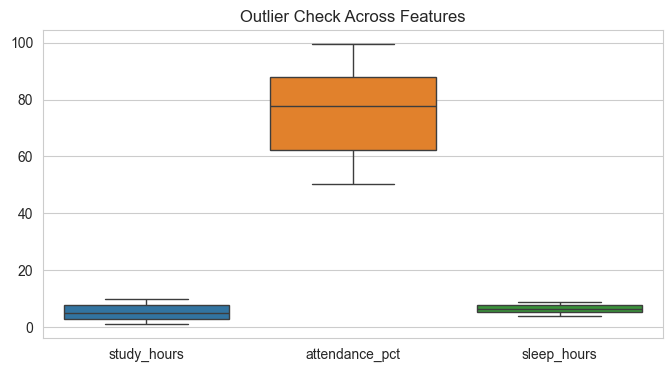

In [13]:
print("Step 3: Check for outliers across all features")
plt.figure(figsize=(8, 4))
sns.boxplot(data=df[["study_hours", "attendance_pct", "sleep_hours"]])
plt.title("Outlier Check Across Features")
plt.show()


In [14]:
print("Step 4: Check correlation with the target")
correlation_with_target = df.corr()["previous_score"].sort_values(ascending=False)
print(correlation_with_target)


Step 4: Check correlation with the target
previous_score    1.000000
study_hours       0.920047
passed            0.835357
attendance_pct    0.280891
sleep_hours      -0.123760
Name: previous_score, dtype: float64


Step 5: Visually confirm class separation before modeling


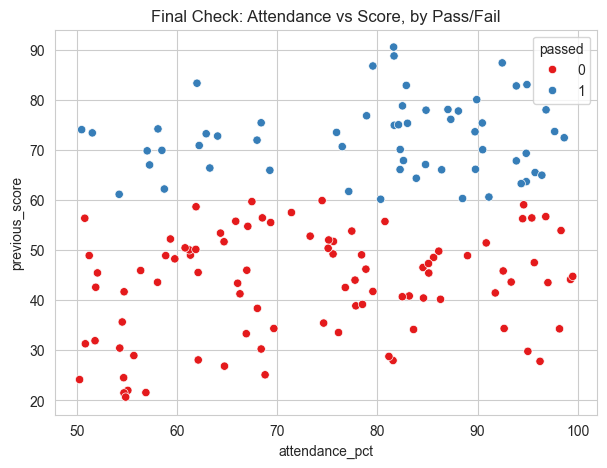


Conclusion: study_hours and attendance_pct both look like strong,
well-separated predictors of previous_score / passed - good candidates
to feed into a model next.


In [15]:
print("Step 5: Visually confirm class separation before modeling")
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="attendance_pct", y="previous_score", hue="passed", palette="Set1")
plt.title("Final Check: Attendance vs Score, by Pass/Fail")
plt.show()

print("\nConclusion: study_hours and attendance_pct both look like strong,")
print("well-separated predictors of previous_score / passed - good candidates")
print("to feed into a model next.")


**This is the real workflow:** shape/stats → distributions → outliers → correlations → class separation. By the time you reach the modeling step, you already know roughly which features matter and whether your data is clean enough to trust.


 Wrap-Up :Where Visualization Fits in ML

3 things to remember:
1. Matplotlib gives you full control over any custom chart; Seaborn gives you fast, good-looking statistical plots that work directly on DataFrames.
2. Boxplots and histograms catch outliers and skew that summary statistics alone can hide.
3. Heatmaps and hue-based scatterplots are how you decide which features are worth feeding into a model, before you ever train one.

Load data (Pandas) → Visualize (Matplotlib/Seaborn) → Clean & engineer features →
.to_numpy() → Train model → Visualize results (loss curves, confusion matrices)

